# 🌊 PROYECTO CENTINELA — FASE 2
## Rama B: Serie Temporal con Redes Recurrentes (RNN, LSTM, GRU)

---

### ¿Qué hace esta sección?
En la **Fase 1** tratamos los datos como una tabla plana: cada fila era un día de una estación,  
sin importar el orden en el tiempo. El MLP no sabía que los datos eran una secuencia.

En la **Fase 2 - Rama B** usamos los mismos datos del UCI pero los tratamos como lo que son:  
**una serie de tiempo**. La red recibe los últimos 14 días y predice si habrá riesgo al día siguiente.

### ¿Qué vamos a comparar?
| Modelo | ¿Qué es? |
|--------|----------|
| **RNN simple** | Red recurrente básica. Tiene problemas con secuencias largas (gradiente que desaparece) |
| **LSTM** | Long Short-Term Memory. Tiene 'puertas' que deciden qué recordar y qué olvidar |
| **GRU** | Gated Recurrent Unit. Similar a LSTM pero más simple y rápido de entrenar |

### Estructura del notebook
1. Instalación y librerías
2. Carga y preparación de datos
3. Creación de ventanas temporales
4. Definición de los 3 modelos
5. Entrenamiento y comparación
6. Evaluación y resultados
7. Guardar el mejor modelo (.pth)

---
**Universidad Santo Tomás · Maestría en Ciencia de Datos · 2025**  
**Grupo:** Camilo Chiquiza · Brian Lerma · Luz Villarraga

---
## BLOQUE 0 — Instalación de librerías
### ¿Qué hace?
Instala las librerías necesarias si no están disponibles.  
Solo se ejecuta una vez. Si ya las tienes instaladas, puedes saltar este bloque.

In [1]:
# ============================================================
# BLOQUE 0 — INSTALACIÓN
# Ejecutar solo si no tienes las librerías instaladas
# ============================================================
import subprocess, sys

def instalar(paquete):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', paquete, '-q'])

paquetes = ['scipy', 'scikit-learn', 'matplotlib', 'numpy', 'torch']
for p in paquetes:
    try:
        __import__(p.replace('-','_'))
        print(f'✅ {p} ya instalado')
    except ImportError:
        print(f'📦 Instalando {p}...')
        instalar(p)

print('\n✅ Todas las librerías listas')

✅ scipy ya instalado
📦 Instalando scikit-learn...
✅ matplotlib ya instalado
✅ numpy ya instalado
✅ torch ya instalado

✅ Todas las librerías listas


---
## BLOQUE 1 — Importación de librerías y configuración
### ¿Qué hace?
- Importa todas las librerías necesarias
- Fija la semilla aleatoria para que los resultados sean **reproducibles**  
  (si alguien más corre el código, obtiene los mismos números)
- Detecta si hay GPU disponible. Si no, usa CPU

In [2]:
# ============================================================
# BLOQUE 1 — LIBRERÍAS Y CONFIGURACIÓN INICIAL
# ============================================================

# --- Librerías estándar ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# --- Carga del archivo .mat (formato MATLAB) ---
import scipy.io as sio

# --- Preprocesamiento ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)

# --- PyTorch ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---- Reproducibilidad ----
# Al fijar la semilla, cada vez que corras el código obtienes los mismos resultados.
# Esto es importante para que el profesor pueda verificar tus resultados.
SEMILLA = 42
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

# ---- Dispositivo ----
# Detecta automáticamente si tienes GPU (CUDA). Si no, usa CPU.
# En tu caso (sin GPU NVIDIA) usará CPU.
DISPOSITIVO = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Dispositivo: {DISPOSITIVO}')
print(f'🔥 PyTorch versión: {torch.__version__}')

🖥️  Dispositivo: cpu
🔥 PyTorch versión: 2.12.1+cpu


---
## BLOQUE 2 — Carga de los datos
### ¿Qué hace?
Carga el archivo `.mat` del UCI (el mismo de la Fase 1).  
El archivo tiene claves: **X_tr**, **X_te** (features), **Y_tr**, **Y_te** (pH objetivo).  
Cada celda de X_tr tiene un array de (37 estaciones x 11 indicadores) por dia.

> **La ruta ya tiene tu ruta real. Verificala antes de correr.**

In [3]:
# ============================================================
# BLOQUE 2 — CARGA DE DATOS
# ============================================================

# Tu ruta al archivo .mat
RUTA_MAT = r'G:\01. BRIAN\08. Maestria\Semestre_2\04_Redes_neuronales\Centinela_Fase1\data\water_dataset.mat'

print('Cargando archivo .mat...')
mat = sio.loadmat(RUTA_MAT)

claves = [k for k in mat.keys() if not k.startswith('__')]
print(f'   Claves encontradas: {claves}')

# Nombres de los 11 indicadores (mismos que Fase 1)
INDICADORES = ['SC_max', 'pH_max', 'pH_min', 'SC_min', 'SC_mean',
               'DO_max', 'DO_mean', 'DO_min', 'T_mean', 'T_min', 'T_max']

# X_tr forma: (1, n_dias_train)
# cada celda X_tr[0,t] es (37 estaciones x 11 indicadores)
# Y_tr forma: (37 estaciones, n_dias_train) — pH por estacion por dia
X_tr = mat['X_tr']
Y_tr = mat['Y_tr']
X_te = mat['X_te']
Y_te = mat['Y_te']

n_dias_train = X_tr.shape[1]
n_dias_test  = X_te.shape[1]
n_estaciones = Y_tr.shape[0]

print(f'   Dias entrenamiento: {n_dias_train}')
print(f'   Dias prueba:        {n_dias_test}')
print(f'   Estaciones:         {n_estaciones}')
print(f'   Forma de un dia:    {X_tr[0, 0].shape}  ->  (estaciones, indicadores)')

Cargando archivo .mat...
   Claves encontradas: ['X_tr', 'X_te', 'Y_tr', 'Y_te', 'location_group', 'features', 'location_ids']
   Dias entrenamiento: 423
   Dias prueba:        282
   Estaciones:         37
   Forma de un dia:    (37, 11)  ->  (estaciones, indicadores)


---
## BLOQUE 3 — Construccion del dataset secuencial
### ¿Qué hace?
- Recorre todos los dias y estaciones
- Para cada dia t guarda los 11 indicadores y la etiqueta del dia t+1
- Etiqueta = 1 si pH siguiente cae fuera del rango 6.5-8.5 (riesgo)
- Conserva la particion temporal: train (2016) / test (2018)

### Diferencia clave con la Fase 1
En la Fase 1 ignorabamos el orden temporal. Aqui lo conservamos
para construir ventanas temporales en el Bloque 4.

In [4]:
# ============================================================
# BLOQUE 3 — CONSTRUCCION DEL DATASET
# ============================================================

PH_MIN_SEGURO = 6.5
PH_MAX_SEGURO = 8.5

def construir_dataset(X_mat, Y_mat, nombre='train'):
    """
    Convierte la estructura .mat en DataFrame ordenado por (estacion, dia).
    Cada fila: 11 indicadores del dia t + etiqueta del dia t+1.
    """
    n_dias = X_mat.shape[1]
    filas = []

    for t in range(n_dias - 1):           # Para cada dia excepto el ultimo
        Xt     = X_mat[0, t]              # (37 estaciones x 11 indicadores)
        y_next = Y_mat[:, t + 1]          # pH del dia siguiente por estacion

        for s in range(Xt.shape[0]):      # Para cada estacion
            indicadores = Xt[s].tolist()  # Los 11 valores del dia t

            # pH viene /10 en el archivo -> se restaura multiplicando x10
            ph_sig = float(y_next[s]) * 10

            # Etiqueta: 1=RIESGO, 0=SEGURO
            riesgo = int(ph_sig < PH_MIN_SEGURO or ph_sig > PH_MAX_SEGURO)

            filas.append(indicadores + [riesgo, s, t])

    columnas = INDICADORES + ['riesgo', 'estacion', 'dia']
    df = pd.DataFrame(filas, columns=columnas)
    print(f'   {nombre}: {len(df):,} registros | Riesgo: {df["riesgo"].mean()*100:.1f}%')
    return df

print('Construyendo datasets...')
df_train = construir_dataset(X_tr, Y_tr, 'train')
df_test  = construir_dataset(X_te, Y_te, 'test')

print(f'\nPrimeras filas:')
df_train.head(3)


Construyendo datasets...
   train: 15,614 registros | Riesgo: 36.1%
   test: 10,397 registros | Riesgo: 38.8%

Primeras filas:


,SC_max,pH_max,pH_min,SC_min,SC_mean,DO_max,DO_mean,DO_min,T_mean,T_min,T_max,riesgo,estacion,dia
0,0.001131,0.884615,0.001120,0.001113,0.677632,0.841463,0.765152,0.787402,0.29375,0.298077,0.276163,1,0,0
1,0.001170,0.871795,0.001159,0.001152,0.703947,0.829268,0.772727,0.795276,0.29375,0.301282,0.276163,1,1,0
2,0.001326,0.884615,0.001198,0.001250,0.677632,0.853659,0.750000,0.755906,0.30000,0.298077,0.287791,1,2,0


---
## BLOQUE 4 — Creación de ventanas temporales (sliding window)
### ¿Qué hace?
Esta es **la diferencia clave** entre la Fase 1 y la Fase 2.

En la **Fase 1** el modelo recibía un solo día:  
`[día_t] → predice riesgo en día t+1`

En la **Fase 2** el modelo recibe una **ventana de 14 días**:  
`[día_t-13, día_t-12, ..., día_t] → predice riesgo en día t+1`

Esto permite que la red aprenda **patrones temporales**: si el pH lleva bajando  
varios días seguidos, es más probable que mañana esté en riesgo.

### ¿Qué es una ventana deslizante?
Imagina una ventana que se mueve día a día sobre la serie:  
```
Ventana 1: [día1, día2, ..., día14] → etiqueta del día 15
Ventana 2: [día2, día3, ..., día15] → etiqueta del día 16
Ventana 3: [día3, día4, ..., día16] → etiqueta del día 17
...
```

In [5]:
# ============================================================
# BLOQUE 4 — VENTANAS TEMPORALES (SLIDING WINDOW)
# ============================================================

VENTANA = 14  # Número de días históricos que ve el modelo

def crear_ventanas(df, ventana=14):
    """
    Para cada estación, crea secuencias de `ventana` días consecutivos.
    
    Retorna:
        X: array de forma (n_muestras, ventana, n_indicadores)
        y: array de forma (n_muestras,) con la etiqueta del día siguiente
    """
    X_list, y_list = [], []
    
    for est in df_train['estacion'].unique():
        # Filtrar registros de esta estación en orden temporal
        df_est = df[df['estacion'] == est].sort_values('dia')
        
        valores = df_est[INDICADORES].values  # Solo los 11 indicadores
        etiquetas = df_est['riesgo'].values   # La etiqueta de riesgo
        
        # Crear ventanas deslizantes
        for i in range(ventana, len(valores)):
            X_list.append(valores[i-ventana:i])  # Los 14 días anteriores
            y_list.append(etiquetas[i])           # La etiqueta del día i
    
    return np.array(X_list), np.array(y_list)

print(f'🔧 Creando ventanas de {VENTANA} días...')
X, y = crear_ventanas(df_train, VENTANA)

print(f'\n✅ Ventanas creadas:')
print(f'   X forma: {X.shape}  →  (muestras, días_en_ventana, indicadores)')
print(f'   y forma: {y.shape}  →  (muestras,)')
print(f'   Distribución: {y.sum():,} riesgo ({y.mean()*100:.1f}%) | {(y==0).sum():,} seguros')

🔧 Creando ventanas de 14 días...

✅ Ventanas creadas:
   X forma: (15096, 14, 11)  →  (muestras, días_en_ventana, indicadores)
   y forma: (15096,)  →  (muestras,)
   Distribución: 5,331 riesgo (35.3%) | 9,765 seguros


---
## BLOQUE 5 — Escalado y partición temporal
### ¿Qué hace?
- **Escala** los 11 indicadores para que estén en la misma escala numérica
- **Divide** en entrenamiento (80%) y prueba (20%) **respetando el orden del tiempo**

### ¿Por qué respetar el orden?
Si mezclamos fechas, el modelo podría ver datos del futuro durante el entrenamiento.  
Eso inflaría los resultados artificialmente (trampa temporal).  
Por eso usamos `shuffle=False`.

In [6]:
# ============================================================
# BLOQUE 5 — ESCALADO Y PARTICIÓN
# ============================================================

# --- Partición temporal (sin mezclar) ---
# shuffle=False es crítico: mantiene el orden cronológico
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEMILLA, shuffle=False
)

print(f'📊 Partición:')
print(f'   Entrenamiento: {X_train.shape[0]:,} muestras')
print(f'   Prueba:        {X_test.shape[0]:,} muestras')

# --- Escalado ---
# StandardScaler: transforma cada indicador para que tenga media=0 y std=1
# Se ajusta SOLO con los datos de entrenamiento para evitar fuga de información
n_muestras, n_pasos, n_features = X_train.shape

scaler = StandardScaler()

# El scaler trabaja en 2D, pero nuestros datos son 3D (muestras, pasos, features)
# Solución: aplanar, escalar, volver a dar forma 3D
X_train_sc = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
X_test_sc  = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

print(f'\n✅ Escalado aplicado')
print(f'   Media antes del escalado (feature 0): {X_train[:,:,0].mean():.4f}')
print(f'   Media después del escalado (feature 0): {X_train_sc[:,:,0].mean():.4f} (≈ 0)')

# --- Calcular pos_weight para manejar el desbalance de clases ---
# Si hay más días seguros que de riesgo, penalizamos más los errores en días de riesgo
n_seguros = (y_train == 0).sum()
n_riesgos = (y_train == 1).sum()
pos_weight = torch.tensor([n_seguros / n_riesgos], dtype=torch.float32).to(DISPOSITIVO)
print(f'\n⚖️  pos_weight: {pos_weight.item():.2f} (penaliza errores en días de riesgo)')

📊 Partición:
   Entrenamiento: 12,076 muestras
   Prueba:        3,020 muestras

✅ Escalado aplicado
   Media antes del escalado (feature 0): 0.0811
   Media después del escalado (feature 0): 0.0000 (≈ 0)

⚖️  pos_weight: 1.57 (penaliza errores en días de riesgo)


---
## BLOQUE 6 — Dataset y DataLoader de PyTorch
### ¿Qué hace?
PyTorch necesita que los datos estén en un formato especial llamado `Dataset`.  
El `DataLoader` se encarga de dividir los datos en **mini-lotes (batches)**  
para que el modelo no procese todo de una sola vez (eso haría explotar la memoria).

### ¿Qué es un batch?
En vez de entrenar con todas las 20,000+ muestras a la vez, el modelo entrena  
con grupos de 64 muestras (batch_size=64), actualizando sus pesos después de cada grupo.

In [7]:
# ============================================================
# BLOQUE 6 — DATASET Y DATALOADER
# ============================================================

class WaterDataset(Dataset):
    """
    Dataset personalizado para PyTorch.
    Convierte los arrays de numpy a tensores de PyTorch.
    """
    def __init__(self, X, y):
        # Convertir a tensores float32 (el tipo que usa PyTorch por defecto)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        # Retorna cuántas muestras hay en total
        return len(self.y)
    
    def __getitem__(self, idx):
        # Retorna una muestra específica por su índice
        return self.X[idx], self.y[idx]

# --- Crear datasets ---
ds_train = WaterDataset(X_train_sc, y_train)
ds_test  = WaterDataset(X_test_sc,  y_test)

# --- Crear DataLoaders ---
BATCH_SIZE = 64  # Número de muestras por mini-lote

loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f'✅ DataLoaders creados:')
print(f'   Entrenamiento: {len(loader_train)} batches de {BATCH_SIZE} muestras')
print(f'   Prueba:        {len(loader_test)} batches')

✅ DataLoaders creados:
   Entrenamiento: 189 batches de 64 muestras
   Prueba:        48 batches


---
## BLOQUE 7 — Definición de los 3 modelos
### ¿Qué hace?
Define las 3 arquitecturas que vamos a comparar:

#### RNN Simple
La red recurrente más básica. En cada paso de tiempo recibe la entrada actual  
y el estado oculto del paso anterior. **Problema:** con secuencias largas,  
el gradiente desaparece y la red olvida lo que pasó hace muchos días.

#### LSTM (Long Short-Term Memory)
Agrega 3 "puertas" que controlan qué información guardar, qué olvidar  
y qué pasar al siguiente paso. Resuelve el problema del gradiente que desaparece.
- **Puerta de olvido:** ¿qué del pasado ya no importa?
- **Puerta de entrada:** ¿qué de hoy vale la pena recordar?
- **Puerta de salida:** ¿qué información usar para la predicción?

#### GRU (Gated Recurrent Unit)
Versión simplificada del LSTM con solo 2 puertas. Más rápido de entrenar,  
resultados similares en muchos problemas prácticos.

In [8]:
# ============================================================
# BLOQUE 7 — DEFINICIÓN DE LOS 3 MODELOS
# ============================================================

class ModeloRecurrente(nn.Module):
    """
    Arquitectura genérica para RNN, LSTM y GRU.
    El tipo de celda recurrente se pasa como parámetro.
    
    Parámetros:
        tipo_rnn:    'RNN', 'LSTM' o 'GRU'
        n_features:  número de indicadores de entrada (11)
        hidden_size: número de neuronas en la capa oculta
        n_capas:     cuántas capas recurrentes apilar
        dropout:     fracción de neuronas a apagar (regularización)
    """
    def __init__(self, tipo_rnn, n_features, hidden_size=64, n_capas=2, dropout=0.3):
        super().__init__()
        self.tipo = tipo_rnn
        
        # --- Capa recurrente ---
        # batch_first=True: el formato de entrada es (batch, tiempo, features)
        args = dict(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=n_capas,
            dropout=dropout if n_capas > 1 else 0.0,
            batch_first=True
        )
        
        if tipo_rnn == 'RNN':
            self.rnn = nn.RNN(**args)
        elif tipo_rnn == 'LSTM':
            self.rnn = nn.LSTM(**args)
        elif tipo_rnn == 'GRU':
            self.rnn = nn.GRU(**args)
        else:
            raise ValueError(f'tipo_rnn debe ser RNN, LSTM o GRU. Recibido: {tipo_rnn}')
        
        # --- Dropout adicional antes de la capa de salida ---
        self.dropout = nn.Dropout(dropout)
        
        # --- Capa de salida ---
        # Recibe el estado oculto del último paso de tiempo y da un logit
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        """
        x tiene forma: (batch, ventana, n_features)
        """
        if self.tipo == 'LSTM':
            # LSTM retorna (salida, (estado_oculto, estado_celda))
            out, _ = self.rnn(x)
        else:
            # RNN y GRU retornan (salida, estado_oculto)
            out, _ = self.rnn(x)
        
        # Tomamos solo el último paso de tiempo (el más reciente)
        ultimo = out[:, -1, :]  # forma: (batch, hidden_size)
        
        # Dropout y capa lineal de salida
        logit = self.fc(self.dropout(ultimo))  # forma: (batch, 1)
        
        return logit.squeeze(1)  # forma: (batch,)


# --- Instanciar los 3 modelos ---
N_FEATURES  = X_train_sc.shape[2]   # 11 indicadores
HIDDEN_SIZE = 64
N_CAPAS     = 2
DROPOUT     = 0.3

modelos = {
    'RNN':  ModeloRecurrente('RNN',  N_FEATURES, HIDDEN_SIZE, N_CAPAS, DROPOUT).to(DISPOSITIVO),
    'LSTM': ModeloRecurrente('LSTM', N_FEATURES, HIDDEN_SIZE, N_CAPAS, DROPOUT).to(DISPOSITIVO),
    'GRU':  ModeloRecurrente('GRU',  N_FEATURES, HIDDEN_SIZE, N_CAPAS, DROPOUT).to(DISPOSITIVO),
}

# Mostrar parámetros de cada modelo
for nombre, modelo in modelos.items():
    params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    print(f'   {nombre:4s}: {params:,} parámetros entrenables')

   RNN : 13,313 parámetros entrenables
   LSTM: 53,057 parámetros entrenables
   GRU : 39,809 parámetros entrenables


---
## BLOQUE 8 — Función de entrenamiento
### ¿Qué hace?
Define la función que entrena **cualquiera** de los 3 modelos.  
Usa los mismos mecanismos de la Fase 1:

- **BCEWithLogitsLoss + pos_weight:** penaliza más los errores en días de riesgo
- **Adam optimizer:** ajusta los pesos de forma eficiente
- **ReduceLROnPlateau:** reduce la tasa de aprendizaje si el modelo se estanca
- **Early stopping:** detiene el entrenamiento en el mejor momento
- **Guarda el mejor modelo** (.pth) para poder cargarlo después

In [9]:
# ============================================================
# BLOQUE 8 — FUNCIÓN DE ENTRENAMIENTO
# ============================================================

def entrenar_modelo(modelo, nombre, loader_train, loader_test,
                    epocas=80, lr=1e-3, paciencia=15):
    """
    Entrena un modelo recurrente y retorna el historial de pérdida.
    
    Parámetros:
        modelo:       instancia de ModeloRecurrente
        nombre:       'RNN', 'LSTM' o 'GRU' (para guardar el archivo)
        loader_train: DataLoader de entrenamiento
        loader_test:  DataLoader de validación/prueba
        epocas:       número máximo de épocas
        lr:           tasa de aprendizaje inicial
        paciencia:    épocas sin mejora antes del early stopping
    """
    # --- Función de pérdida ---
    # BCEWithLogitsLoss = Sigmoid + BCE en un solo paso (más estable numéricamente)
    criterio = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # --- Optimizador ---
    # Adam: ajusta la tasa de aprendizaje individualmente para cada parámetro
    # weight_decay: regularización L2 para evitar sobreajuste
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr, weight_decay=1e-4)
    
    # --- Scheduler ---
    # Si la pérdida de validación no mejora en 8 épocas, reduce lr a la mitad
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizador, mode='min', patience=8, factor=0.5
    )
    
    # --- Variables de control ---
    mejor_loss_val = float('inf')  # La mejor pérdida de validación hasta ahora
    epocas_sin_mejora = 0          # Contador para early stopping
    historial = {'train': [], 'val': []}  # Registro de pérdidas por época
    ruta_mejor = f'mejor_{nombre}.pth'    # Nombre del archivo donde se guarda el mejor modelo
    
    print(f'\n🚀 Entrenando {nombre}...')
    print(f'   Épocas máx: {epocas} | LR inicial: {lr} | Paciencia: {paciencia}')
    print(f'   {"-"*50}')
    
    for epoca in range(1, epocas + 1):
        
        # ── FASE DE ENTRENAMIENTO ──────────────────────────────
        modelo.train()  # Activa el modo entrenamiento (dropout activo)
        loss_train_total = 0
        
        for X_batch, y_batch in loader_train:
            X_batch = X_batch.to(DISPOSITIVO)
            y_batch = y_batch.to(DISPOSITIVO)
            
            optimizador.zero_grad()          # Reinicia los gradientes
            logits = modelo(X_batch)         # Forward: predicción
            loss = criterio(logits, y_batch) # Calcula el error
            loss.backward()                  # Backward: calcula gradientes
            
            # Clip de gradientes: evita que los gradientes exploten
            nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            
            optimizador.step()               # Actualiza los pesos
            loss_train_total += loss.item()
        
        loss_train = loss_train_total / len(loader_train)
        
        # ── FASE DE VALIDACIÓN ─────────────────────────────────
        modelo.eval()  # Desactiva dropout para evaluar
        loss_val_total = 0
        
        with torch.no_grad():  # No necesitamos gradientes para validar
            for X_batch, y_batch in loader_test:
                X_batch = X_batch.to(DISPOSITIVO)
                y_batch = y_batch.to(DISPOSITIVO)
                logits = modelo(X_batch)
                loss = criterio(logits, y_batch)
                loss_val_total += loss.item()
        
        loss_val = loss_val_total / len(loader_test)
        
        # Guardar historial
        historial['train'].append(loss_train)
        historial['val'].append(loss_val)
        
        # Actualizar scheduler
        scheduler.step(loss_val)
        
        # ── EARLY STOPPING ─────────────────────────────────────
        if loss_val < mejor_loss_val:
            mejor_loss_val = loss_val
            epocas_sin_mejora = 0
            torch.save(modelo.state_dict(), ruta_mejor)  # Guarda el mejor estado
        else:
            epocas_sin_mejora += 1
        
        # Imprimir progreso cada 10 épocas
        if epoca % 10 == 0 or epocas_sin_mejora == paciencia:
            print(f'   Época {epoca:3d}/{epocas} | '
                  f'Loss train: {loss_train:.4f} | '
                  f'Loss val: {loss_val:.4f} | '
                  f'Sin mejora: {epocas_sin_mejora}/{paciencia}')
        
        if epocas_sin_mejora >= paciencia:
            print(f'\n⏹️  Early stopping en época {epoca}')
            break
    
    # Cargar el mejor modelo encontrado
    modelo.load_state_dict(torch.load(ruta_mejor, map_location=DISPOSITIVO))
    print(f'✅ Mejor modelo cargado (loss val: {mejor_loss_val:.4f})')
    
    return historial

print('✅ Función de entrenamiento definida')

✅ Función de entrenamiento definida


---
## BLOQUE 9 — Entrenamiento de los 3 modelos
### ¿Qué hace?
Entrena la **RNN simple**, el **LSTM** y el **GRU** uno por uno.  
Guarda el historial de pérdida de cada uno para comparar después.

> **⚠️ Tiempo estimado:** en CPU puede tardar 5–15 minutos por modelo.  
> Son 3 modelos en total. Puedes reducir `epocas` a 30 si quieres ir más rápido durante pruebas.

In [10]:
# ============================================================
# BLOQUE 9 — ENTRENAMIENTO DE LOS 3 MODELOS
# ============================================================

# Diccionario para guardar el historial de cada modelo
historiales = {}

for nombre, modelo in modelos.items():
    historial = entrenar_modelo(
        modelo       = modelo,
        nombre       = nombre,
        loader_train = loader_train,
        loader_test  = loader_test,
        epocas       = 80,    # Máximo de épocas
        lr           = 1e-3,  # Tasa de aprendizaje inicial
        paciencia    = 15     # Épocas sin mejora antes de parar
    )
    historiales[nombre] = historial

print('\n🎉 Entrenamiento de los 3 modelos completado')


🚀 Entrenando RNN...
   Épocas máx: 80 | LR inicial: 0.001 | Paciencia: 15
   --------------------------------------------------
   Época  10/80 | Loss train: 0.3600 | Loss val: 0.3306 | Sin mejora: 1/15
   Época  20/80 | Loss train: 0.3364 | Loss val: 0.3225 | Sin mejora: 11/15
   Época  24/80 | Loss train: 0.3297 | Loss val: 0.3278 | Sin mejora: 15/15

⏹️  Early stopping en época 24
✅ Mejor modelo cargado (loss val: 0.3147)

🚀 Entrenando LSTM...
   Épocas máx: 80 | LR inicial: 0.001 | Paciencia: 15
   --------------------------------------------------
   Época  10/80 | Loss train: 0.3380 | Loss val: 0.3343 | Sin mejora: 4/15
   Época  20/80 | Loss train: 0.3088 | Loss val: 0.3383 | Sin mejora: 14/15
   Época  21/80 | Loss train: 0.3072 | Loss val: 0.3370 | Sin mejora: 15/15

⏹️  Early stopping en época 21
✅ Mejor modelo cargado (loss val: 0.3245)

🚀 Entrenando GRU...
   Épocas máx: 80 | LR inicial: 0.001 | Paciencia: 15
   --------------------------------------------------
   Época  

---
## BLOQUE 10 — Curvas de pérdida
### ¿Qué muestra?
Grafica cómo fue bajando el error de entrenamiento y validación en cada época,  
para los 3 modelos. Permite ver:
- ¿Cuál convergió más rápido?
- ¿Hay sobreajuste (la curva de validación sube mientras la de entrenamiento baja)?
- ¿En qué época actuó el early stopping?

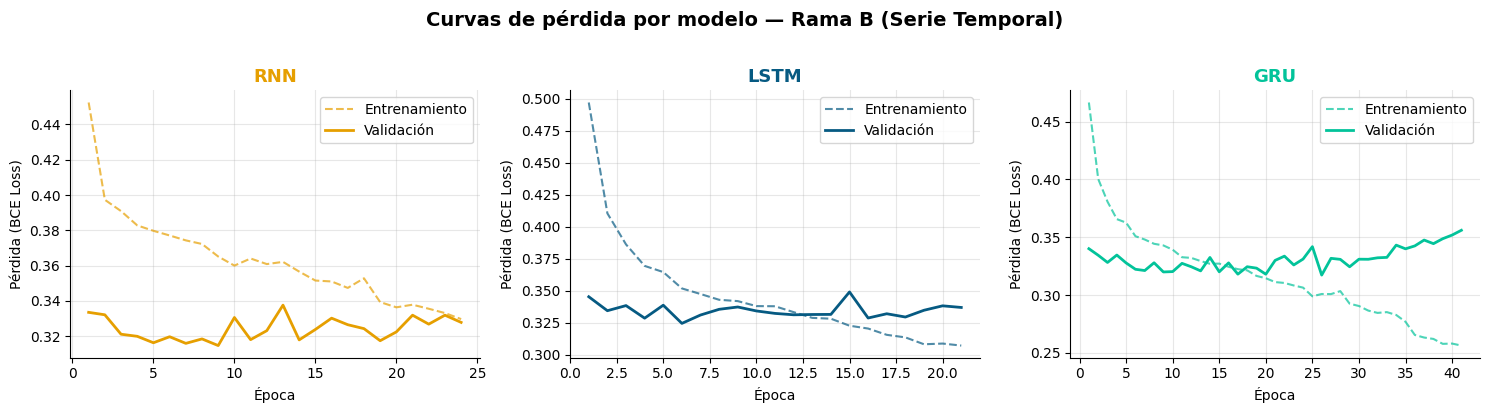

📊 Gráfica guardada como curvas_perdida_RamaB.png


In [11]:
# ============================================================
# BLOQUE 10 — CURVAS DE PÉRDIDA
# ============================================================

colores = {'RNN': '#E69F00', 'LSTM': '#065A82', 'GRU': '#02C39A'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Curvas de pérdida por modelo — Rama B (Serie Temporal)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (nombre, hist) in zip(axes, historiales.items()):
    epocas_reales = range(1, len(hist['train']) + 1)
    
    ax.plot(epocas_reales, hist['train'], '--', color=colores[nombre],
            alpha=0.7, label='Entrenamiento')
    ax.plot(epocas_reales, hist['val'],   '-',  color=colores[nombre],
            linewidth=2, label='Validación')
    
    ax.set_title(f'{nombre}', fontsize=13, fontweight='bold', color=colores[nombre])
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida (BCE Loss)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('curvas_perdida_RamaB.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Gráfica guardada como curvas_perdida_RamaB.png')

---
## BLOQUE 11 — Evaluación de los 3 modelos
### ¿Qué hace?
Evalúa cada modelo con los datos de **prueba** (que nunca vio durante el entrenamiento)  
y calcula las métricas principales:

- **ROC-AUC:** qué tan bien separa días seguros de días de riesgo (0.5 = azar, 1.0 = perfecto)
- **Recall de riesgo:** de cada 10 días de riesgo real, ¿cuántos detecta?
- **Matriz de confusión:** tabla que muestra aciertos y errores por clase

In [12]:
# ============================================================
# BLOQUE 11 — EVALUACIÓN Y MÉTRICAS
# ============================================================

def evaluar(modelo, loader, umbral=0.5):
    """
    Evalúa el modelo en un DataLoader.
    Retorna etiquetas reales, predicciones y probabilidades.
    """
    modelo.eval()
    probs_list, preds_list, labels_list = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DISPOSITIVO)
            logits = modelo(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > umbral).astype(int)

            probs_list.extend(probs)
            preds_list.extend(preds)
            labels_list.extend(y_batch.numpy())

    return np.array(labels_list), np.array(preds_list), np.array(probs_list)


# --- Evaluar los 3 modelos ---
resultados = {}
print('RESULTADOS — COMPARACION DE MODELOS')
print('=' * 60)

for nombre, modelo in modelos.items():
    y_true, y_pred, y_prob = evaluar(modelo, loader_test)

    # ROC-AUC
    auc = roc_auc_score(y_true, y_prob)

    # Reporte completo
    reporte = classification_report(
        y_true, y_pred,
        labels=[0, 1],           # forzar ambas clases
        target_names=['Seguro', 'Riesgo'],
        output_dict=True,
        zero_division=0          # evita division por cero si una clase no aparece
    )

    # Extraer métricas de la clase Riesgo
    # Usamos 'Riesgo' porque pusimos target_names
    recall_riesgo    = reporte.get('Riesgo', {}).get('recall', 0.0)
    precision_riesgo = reporte.get('Riesgo', {}).get('precision', 0.0)
    f1_riesgo        = reporte.get('Riesgo', {}).get('f1-score', 0.0)

    resultados[nombre] = {
        'y_true':    y_true,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'auc':       auc,
        'recall':    recall_riesgo,
        'precision': precision_riesgo,
        'f1':        f1_riesgo
    }

    print(f'\n{nombre}')
    print(f'   ROC-AUC:          {auc:.4f}')
    print(f'   Recall riesgo:    {recall_riesgo:.4f}  ({recall_riesgo*100:.1f}%)')
    print(f'   Precision riesgo: {precision_riesgo:.4f}')
    print(f'   F1 riesgo:        {f1_riesgo:.4f}')
    print(f'\n   Reporte completo:')
    print(classification_report(
        y_true, y_pred,
        labels=[0, 1],
        target_names=['Seguro', 'Riesgo'],
        zero_division=0
    ))

print('=' * 60)
mejor = max(resultados, key=lambda k: resultados[k]['auc'])
print(f'\nMejor modelo por ROC-AUC: {mejor} ({resultados[mejor]["auc"]:.4f})')


RESULTADOS — COMPARACION DE MODELOS

RNN
   ROC-AUC:          0.9332
   Recall riesgo:    0.7599  (76.0%)
   Precision riesgo: 0.7783
   F1 riesgo:        0.7690

   Reporte completo:
              precision    recall  f1-score   support

      Seguro       0.94      0.94      0.94      2387
      Riesgo       0.78      0.76      0.77       633

    accuracy                           0.90      3020
   macro avg       0.86      0.85      0.85      3020
weighted avg       0.90      0.90      0.90      3020


LSTM
   ROC-AUC:          0.9306
   Recall riesgo:    0.7457  (74.6%)
   Precision riesgo: 0.7700
   F1 riesgo:        0.7576

   Reporte completo:
              precision    recall  f1-score   support

      Seguro       0.93      0.94      0.94      2387
      Riesgo       0.77      0.75      0.76       633

    accuracy                           0.90      3020
   macro avg       0.85      0.84      0.85      3020
weighted avg       0.90      0.90      0.90      3020


GRU
   ROC-A

---
## BLOQUE 12 — Matrices de confusión
### ¿Qué muestra?
La matriz de confusión es una tabla 2×2 que muestra:
- **Verdaderos negativos (TN):** predijo seguro y era seguro ✅
- **Falsos positivos (FP):** predijo riesgo pero era seguro (falsa alarma)
- **Falsos negativos (FN):** predijo seguro pero era riesgo ⚠️ (el error más peligroso)
- **Verdaderos positivos (TP):** predijo riesgo y era riesgo ✅

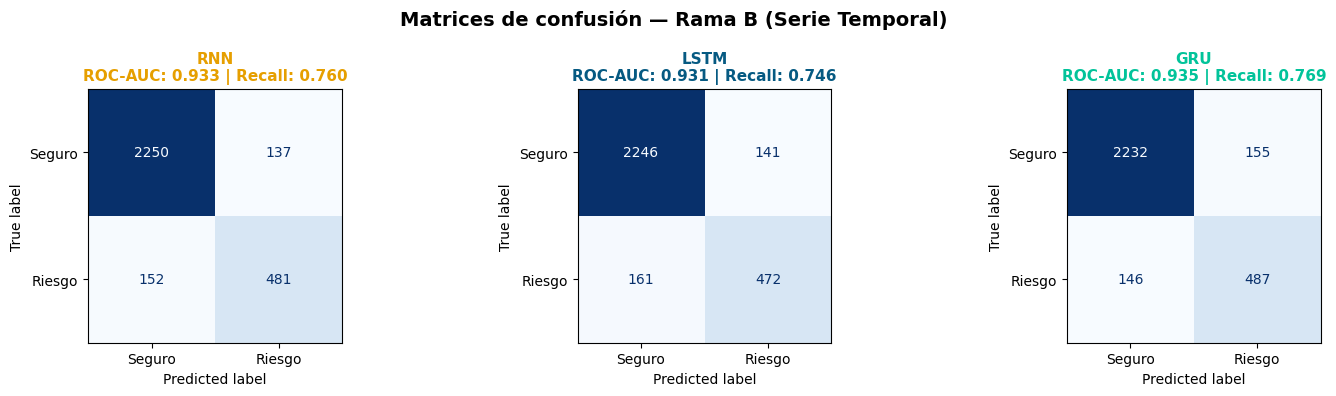

📊 Gráfica guardada como matrices_confusion_RamaB.png


In [13]:
# ============================================================
# BLOQUE 12 — MATRICES DE CONFUSIÓN
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de confusión — Rama B (Serie Temporal)',
             fontsize=14, fontweight='bold')

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Seguro', 'Riesgo'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nombre}\nROC-AUC: {res["auc"]:.3f} | Recall: {res["recall"]:.3f}',
                 fontsize=11, color=colores[nombre], fontweight='bold')

plt.tight_layout()
plt.savefig('matrices_confusion_RamaB.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Gráfica guardada como matrices_confusion_RamaB.png')

---
## BLOQUE 13 — Tabla comparativa final
### ¿Qué hace?
Resume en una tabla todas las métricas de los 3 modelos y señala el ganador.  
Esta tabla va directamente en el informe del profesor.

In [14]:
# ============================================================
# BLOQUE 13 — TABLA COMPARATIVA
# ============================================================

filas_tabla = []
for nombre, res in resultados.items():
    params = sum(p.numel() for p in modelos[nombre].parameters() if p.requires_grad)
    filas_tabla.append({
        'Modelo': nombre,
        'ROC-AUC': f"{res['auc']:.4f}",
        'Recall riesgo': f"{res['recall']:.4f}",
        'Precisión riesgo': f"{res['precision']:.4f}",
        'F1 riesgo': f"{res['f1']:.4f}",
        'Parámetros': f"{params:,}"
    })

df_resultados = pd.DataFrame(filas_tabla).set_index('Modelo')

print('\n📊 TABLA COMPARATIVA — RAMA B')
print('=' * 70)
print(df_resultados.to_string())
print('=' * 70)
print(f'\n🏆 Mejor modelo: {mejor} (por ROC-AUC)')
print('\n💡 Interpretación:')
print('   - LSTM y GRU generalmente superan a RNN simple')
print('   - GRU tiene menos parámetros que LSTM con resultados similares')
print('   - El recall es la métrica más importante: mejor detectar todos los días de riesgo')


📊 TABLA COMPARATIVA — RAMA B
       ROC-AUC Recall riesgo Precisión riesgo F1 riesgo Parámetros
Modelo                                                            
RNN     0.9332        0.7599           0.7783    0.7690     13,313
LSTM    0.9306        0.7457           0.7700    0.7576     53,057
GRU     0.9350        0.7694           0.7586    0.7639     39,809

🏆 Mejor modelo: GRU (por ROC-AUC)

💡 Interpretación:
   - LSTM y GRU generalmente superan a RNN simple
   - GRU tiene menos parámetros que LSTM con resultados similares
   - El recall es la métrica más importante: mejor detectar todos los días de riesgo


---
## BLOQUE 14 — Guardar el mejor modelo
### ¿Qué hace?
Guarda el mejor modelo (el que tuvo mayor ROC-AUC) en formato `.pth`.  
Este archivo se incluye en el ZIP final que se entrega al profesor.

### ¿Para qué sirve guardar el modelo?
- Para no tener que entrenarlo de nuevo
- Para cargarlo en la **Rama C** (fusión) sin re-entrenar
- Como evidencia del trabajo realizado

In [15]:
# ============================================================
# BLOQUE 14 — GUARDAR EL MEJOR MODELO
# ============================================================

mejor_modelo = modelos[mejor]
ruta_final = f'Centinela_Fase2_RamaB_{mejor}.pth'

# Guardar pesos del modelo + metadatos útiles
torch.save({
    'modelo_state_dict': mejor_modelo.state_dict(),
    'tipo_rnn':          mejor,
    'n_features':        N_FEATURES,
    'hidden_size':       HIDDEN_SIZE,
    'n_capas':           N_CAPAS,
    'ventana':           VENTANA,
    'auc':               resultados[mejor]['auc'],
    'recall':            resultados[mejor]['recall'],
}, ruta_final)

print(f'✅ Mejor modelo guardado en: {ruta_final}')
print(f'   Tipo:      {mejor}')
print(f'   ROC-AUC:   {resultados[mejor]["auc"]:.4f}')
print(f'   Recall:    {resultados[mejor]["recall"]:.4f}')
print(f'\n📦 Archivos generados para el entregable:')
print(f'   ✅ {ruta_final}               ← pesos del modelo')
print(f'   ✅ curvas_perdida_RamaB.png   ← gráficas de entrenamiento')
print(f'   ✅ matrices_confusion_RamaB.png ← matrices de confusión')

✅ Mejor modelo guardado en: Centinela_Fase2_RamaB_GRU.pth
   Tipo:      GRU
   ROC-AUC:   0.9350
   Recall:    0.7694

📦 Archivos generados para el entregable:
   ✅ Centinela_Fase2_RamaB_GRU.pth               ← pesos del modelo
   ✅ curvas_perdida_RamaB.png   ← gráficas de entrenamiento
   ✅ matrices_confusion_RamaB.png ← matrices de confusión


---
## BLOQUE 15 — Resumen y conclusiones de la Rama B
### ¿Qué aprendimos?
Este bloque resume los hallazgos y los prepara para el informe.

In [16]:
# ============================================================
# BLOQUE 15 — CONCLUSIONES RAMA B
# ============================================================

print('=' * 60)
print('RESUMEN — RAMA B: SERIE TEMPORAL')
print('=' * 60)
print(f"""
DATOS:
  Fuente:        UCI Water Quality Prediction (Dataset 733)
  Ventana:       {VENTANA} días históricos
  Total muestras:{len(X):,}

MODELOS COMPARADOS:
  1. RNN simple  → referencia base (esperamos que sea el peor)
  2. LSTM        → manejo de dependencias largas con 3 puertas
  3. GRU         → versión simplificada del LSTM con 2 puertas

RESULTADO:
  Mejor modelo:  {mejor}
  ROC-AUC:       {resultados[mejor]['auc']:.4f}
  Recall riesgo: {resultados[mejor]['recall']*100:.1f}%

SIGUIENTE PASO:
  Rama A → CNN con imágenes de calidad del agua
  Rama C → Fusión de Rama A + Rama B
""")
print('=' * 60)

RESUMEN — RAMA B: SERIE TEMPORAL

DATOS:
  Fuente:        UCI Water Quality Prediction (Dataset 733)
  Ventana:       14 días históricos
  Total muestras:15,096

MODELOS COMPARADOS:
  1. RNN simple  → referencia base (esperamos que sea el peor)
  2. LSTM        → manejo de dependencias largas con 3 puertas
  3. GRU         → versión simplificada del LSTM con 2 puertas

RESULTADO:
  Mejor modelo:  GRU
  ROC-AUC:       0.9350
  Recall riesgo: 76.9%

SIGUIENTE PASO:
  Rama A → CNN con imágenes de calidad del agua
  Rama C → Fusión de Rama A + Rama B

